<a href="https://colab.research.google.com/github/deepakkumar-dsa/Loan-Approval-Prediction/blob/main/Loan%20approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem statement
**A bank want to predict whether a loan applicant will Approved or Rejected**

## Import Neccesary Libraries

In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# Save Model
import pickle

## Load Dataset

In [ ]:
loan=pd.read_csv(r"D:\Python learning\New folder\loan_approval_dataset.csv")
loan.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Data Understanding

In [ ]:
loan.shape

(4269, 13)

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
loan.isna().sum()

loan_id                      0
no_of_dependents             0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [ ]:
loan.duplicated().sum()

np.int64(0)

In [ ]:
loan.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Data Cleaning

In [ ]:
loan.columns

Index(['loan_id', 'no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
# strip the white space from both sides
loan.columns=loan.columns.str.strip()

In [ ]:
loan['education']=loan['education'].str.strip()
loan['self_employed']=loan['self_employed'].str.strip()
loan['loan_status']=loan['loan_status'].str.strip()

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
loan.drop("loan_id",axis=1,inplace=True)

In [ ]:
cat_cols = loan.select_dtypes(include='object').columns
print(cat_cols)

Index(['education', 'self_employed', 'loan_status'], dtype='object')


In [ ]:
loan['loan_status'] = loan['loan_status'].str.strip()
loan['loan_status'] = loan['loan_status'].str.capitalize()

In [ ]:
# what percentage of applicants get loan approved vs rejected
print(loan['loan_status'].value_counts())
print('==================================')
print(loan['self_employed'].value_counts())
print('===================================')
print(loan['education'].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64


In [ ]:
print(loan['loan_status'].value_counts(normalize=True)*100)
print('====================================================')
print(loan['self_employed'].value_counts(normalize=True)*100)
print('====================================================')
print(loan['education'].value_counts(normalize=True)*100)

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64
self_employed
Yes    50.363083
No     49.636917
Name: proportion, dtype: float64
education
Graduate        50.222535
Not Graduate    49.777465
Name: proportion, dtype: float64


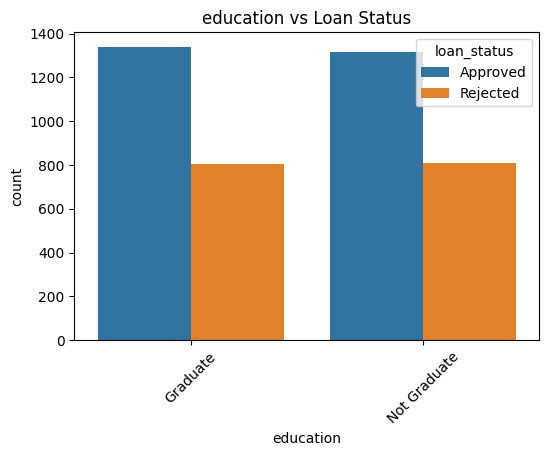

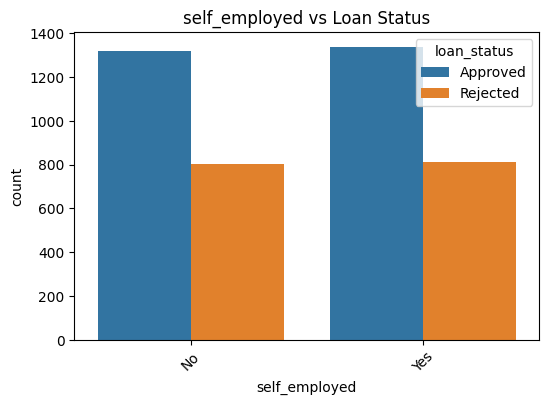

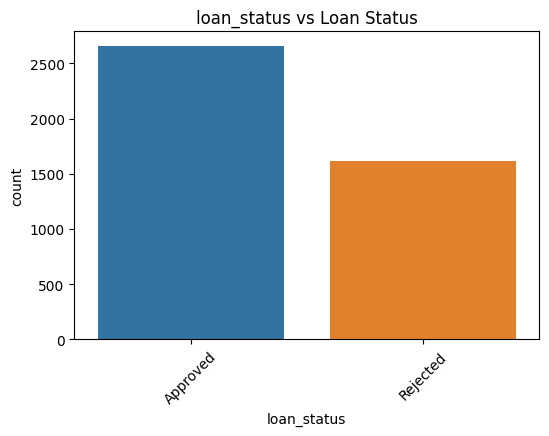

In [ ]:
#categorical columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='loan_status', data=loan)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

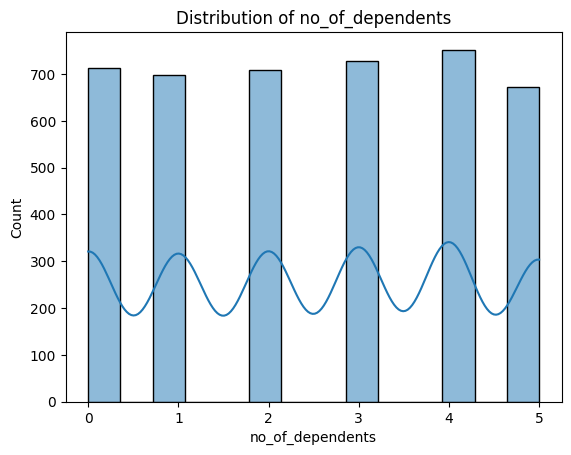

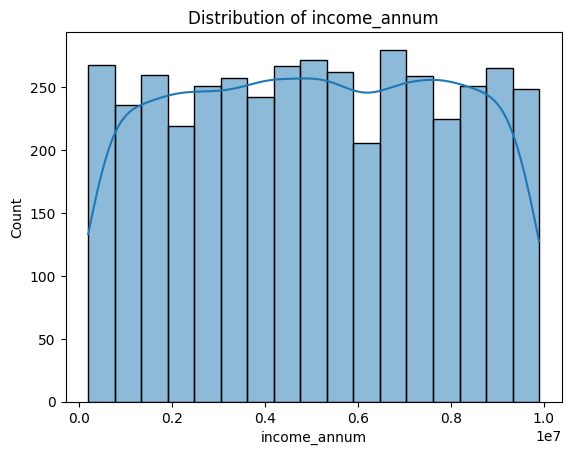

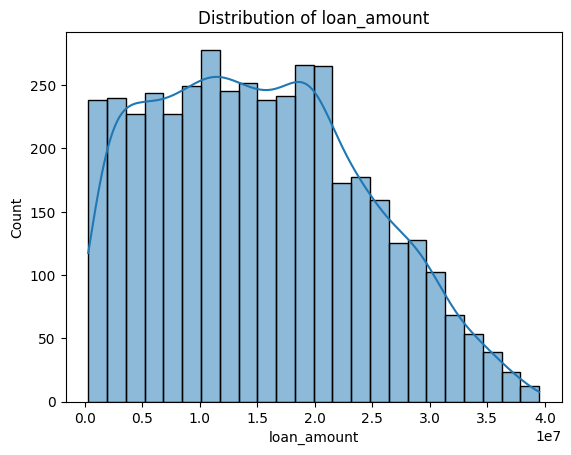

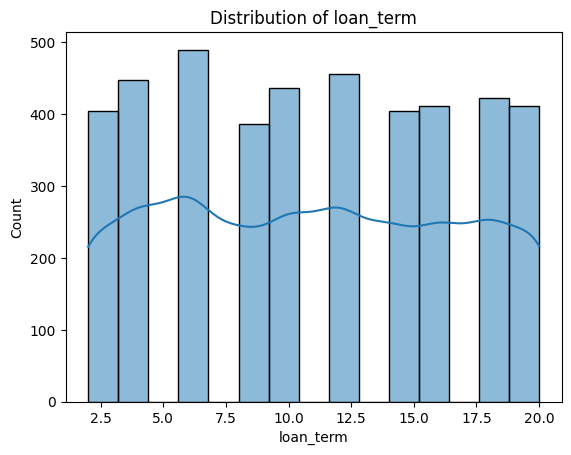

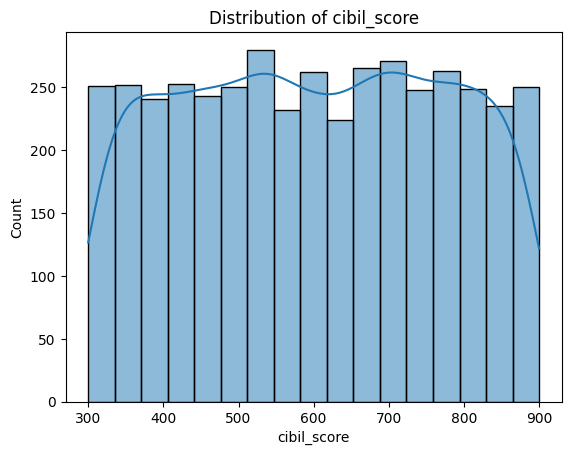

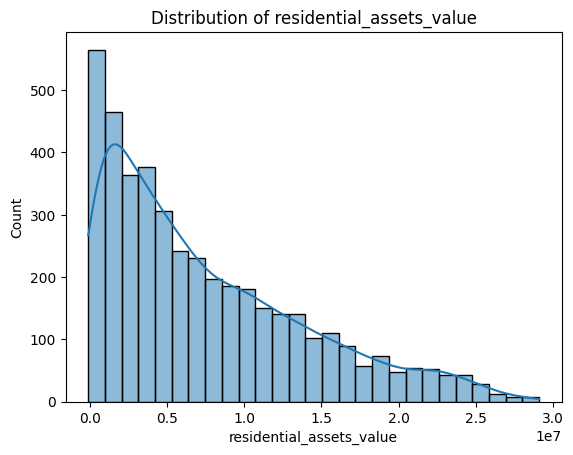

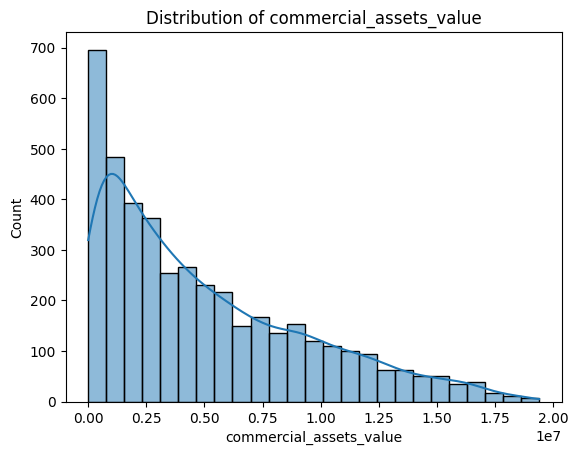

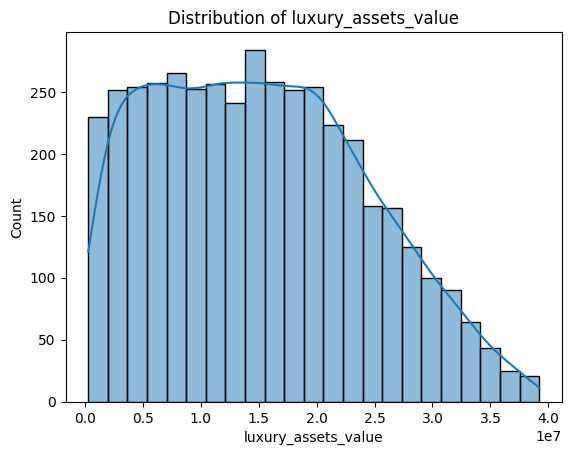

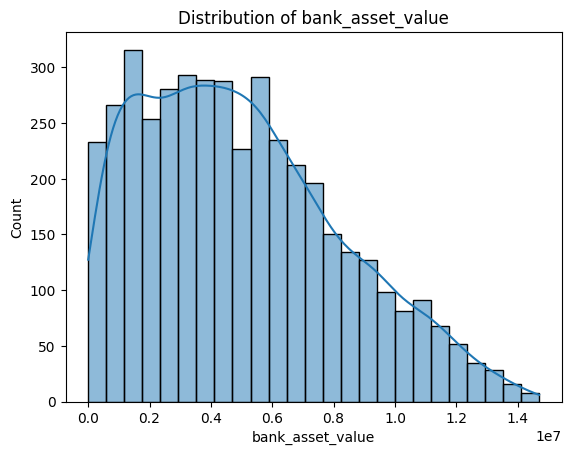

In [ ]:
#numerical columns
num_cols = loan.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(loan[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

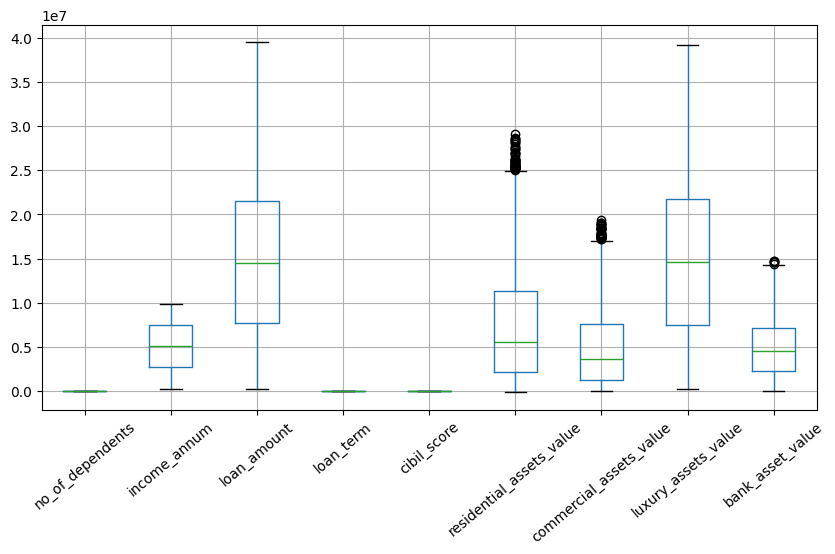

In [ ]:
plt.figure(figsize=(10,5))
loan.boxplot()
plt.xticks(rotation=40)
plt.show()

## Feature Engineering

### Remove Outliers

In [ ]:
#calculate Quartile
Q1_R=loan['residential_assets_value'].quantile(0.25)
Q3_R=loan['residential_assets_value'].quantile(0.75)

#calculate IQR
IQR=Q3_R-Q1_R

lower_limit=Q1_R- 1.5 * IQR
upper_limit=Q3_R+ 1.5 * IQR

In [ ]:
loan=loan[(loan['residential_assets_value'] >=lower_limit) & (loan['residential_assets_value']<=upper_limit)]

In [ ]:
#calculate Quartile
Q1_C=loan['commercial_assets_value'].quantile(0.25)
Q3_C=loan['commercial_assets_value'].quantile(0.75)

#calculate IQR
C_IQR=Q3_C-Q1_C

lower_limit=Q1_C- 1.5 * C_IQR
upper_limit=Q3_C+ 1.5 * C_IQR

In [ ]:
loan=loan[(loan['commercial_assets_value'] >= lower_limit) & (loan['commercial_assets_value']<=upper_limit)]

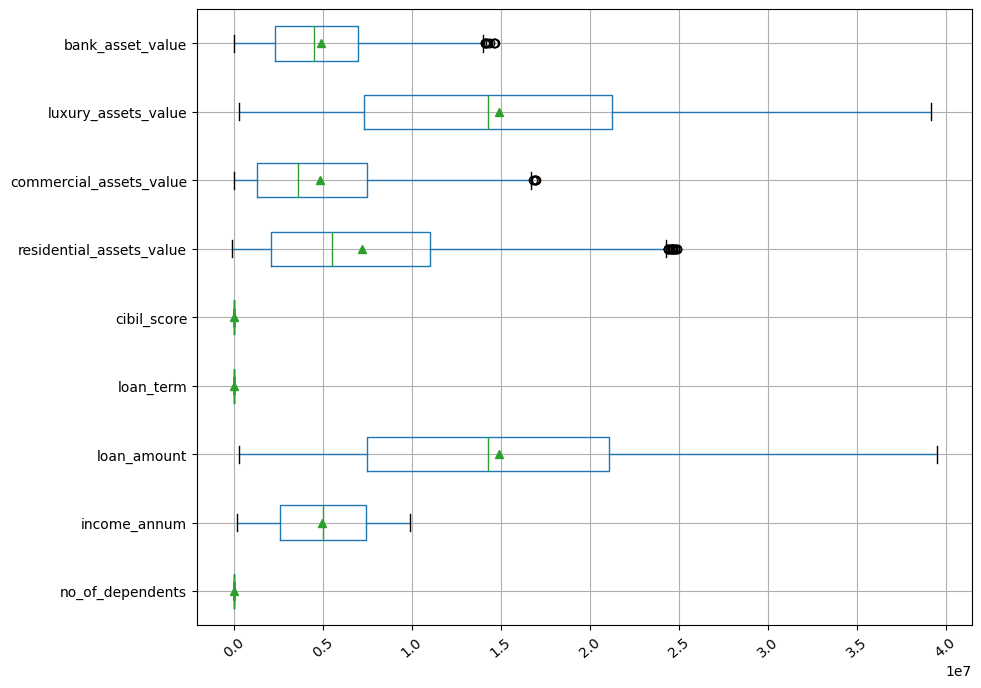

In [ ]:
plt.figure(figsize=(10,8))
loan.boxplot(showmeans=True, vert=False)
plt.xticks(rotation=40)
plt.show()

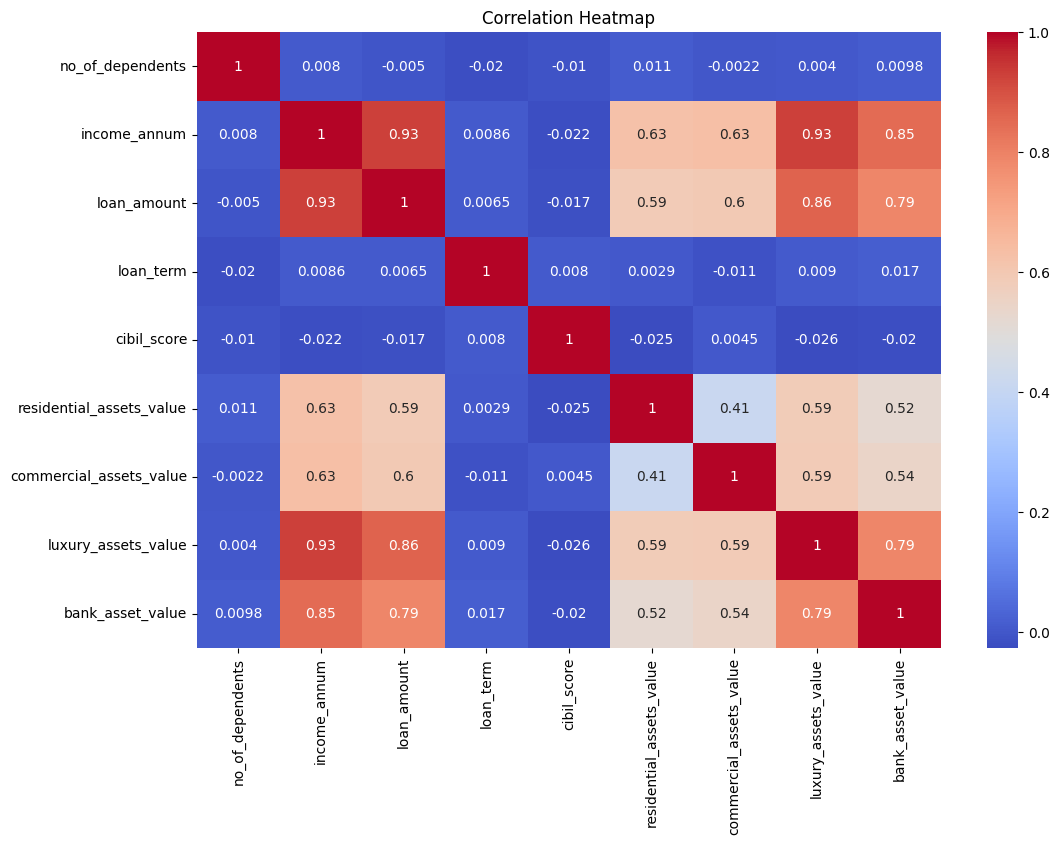

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(loan.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
loan.corr(numeric_only=True)

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.008005,-0.005034,-0.019701,-0.010068,0.010661,-0.002152,0.003954,0.009798
income_annum,0.008005,1.000000,0.927901,0.008631,-0.022204,0.626571,0.633087,0.930122,0.851018
loan_amount,-0.005034,0.927901,1.000000,0.006524,-0.016715,0.589440,0.595765,0.863693,0.789385
loan_term,-0.019701,0.008631,0.006524,1.000000,0.008036,0.002927,-0.010819,0.008991,0.016729
cibil_score,-0.010068,-0.022204,-0.016715,0.008036,1.000000,-0.025360,0.004526,-0.026325,-0.020063
residential_assets_value,0.010661,0.626571,0.589440,0.002927,-0.025360,1.000000,0.411488,0.585632,0.519885
commercial_assets_value,-0.002152,0.633087,0.595765,-0.010819,0.004526,0.411488,1.000000,0.587588,0.544367
luxury_assets_value,0.003954,0.930122,0.863693,0.008991,-0.026325,0.585632,0.587588,1.000000,0.788384
bank_asset_value,0.009798,0.851018,0.789385,0.016729,-0.020063,0.519885,0.544367,0.788384,1.000000


## Encoding

In [ ]:
le=LabelEncoder()


In [ ]:
loan['loan_status'] = loan['loan_status'].map({
    'Rejected': 0,
    'Approved': 1
})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_edu = LabelEncoder()
le_self = LabelEncoder()

loan['education'] = le_edu.fit_transform(loan['education'])
loan['self_employed'] = le_self.fit_transform(loan['self_employed'])

In [ ]:
encoders = {
    'education': le_edu,
    'self_employed': le_self
}

pickle.dump(encoders, open("encoders.pkl", "wb"))

In [ ]:
loan.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4182 entries, 1 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4182 non-null   int64
 1   education                 4182 non-null   int64
 2   self_employed             4182 non-null   int64
 3   income_annum              4182 non-null   int64
 4   loan_amount               4182 non-null   int64
 5   loan_term                 4182 non-null   int64
 6   cibil_score               4182 non-null   int64
 7   residential_assets_value  4182 non-null   int64
 8   commercial_assets_value   4182 non-null   int64
 9   luxury_assets_value       4182 non-null   int64
 10  bank_asset_value          4182 non-null   int64
 11  loan_status               4182 non-null   int64
dtypes: int64(12)
memory usage: 424.7 KB


## Save Encoder File

In [ ]:
X =loan.drop('loan_status', axis=1)
y = loan['loan_status']

In [ ]:
X

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000
5,0,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [ ]:
y

1       0
2       0
3       0
4       0
5       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4182, dtype: int64

## Train Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [ ]:
X_train.shape

(3345, 11)

In [ ]:
y_train.value_counts()

loan_status
1    2096
0    1249
Name: count, dtype: int64

### Handle Imbalanced Data

In [ ]:
loan.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [ ]:
num_col = ['income_annum','loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value','commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

In [ ]:
scaler = StandardScaler()

X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_sm.value_counts()

loan_status
1    2096
0    2096
Name: count, dtype: int64

In [ ]:
loan.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


### Train Models

In [ ]:
log_model = LogisticRegression(max_iter=1000,class_weight='balanced')

log_model.fit(X_train_sm,y_train_sm)

y_pred_log = log_model.predict(X_test)

print(f"Logistic Regression")
print(f"Accuracy:", accuracy_score(y_test, y_pred_log))
print(f"Confusion Matrix:", confusion_matrix(y_test,y_pred_log))
print(f"Roc -Aoc curve:",roc_auc_score(y_test,y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.9199522102747909
Confusion Matrix: [[310  18]
 [ 49 460]]
Roc -Aoc curve: 0.9244273803248837
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       328
           1       0.96      0.90      0.93       509

    accuracy                           0.92       837
   macro avg       0.91      0.92      0.92       837
weighted avg       0.92      0.92      0.92       837



In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual Value": y_test,
    "Predicted Value": y_pred_log
})

print(results.head(20))

      Actual Value  Predicted Value
1294             0                0
1191             1                1
2271             1                1
826              1                1
3363             0                0
1511             1                1
148              1                1
4213             1                1
1205             0                0
773              0                0
1079             1                1
184              1                1
3140             1                1
171              1                1
505              1                1
667              1                1
3593             0                0
2336             1                1
2949             0                1
3969             0                0


In [ ]:
y_test_pred=log_model.predict(X_test)
y_train_pred=log_model.predict(X_train)

In [ ]:
accuracy_score(y_test,y_test_pred)

0.9199522102747909

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train_sm, y_train_sm)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(f"Confusion Matrix:", confusion_matrix(y_test,y_pred_dt))
print(f"Roc -Aoc curve:",roc_auc_score(y_test,y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.959378733572282
Confusion Matrix: [[323   5]
 [ 29 480]]
Roc -Aoc curve: 0.9638908189180123
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       328
           1       0.99      0.94      0.97       509

    accuracy                           0.96       837
   macro avg       0.95      0.96      0.96       837
weighted avg       0.96      0.96      0.96       837



In [ ]:
rf_model = RandomForestClassifier(max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Confusion Matrix:", confusion_matrix(y_test,y_pred_rf))
print(f"Roc -Aoc curve:",roc_auc_score(y_test,y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.953405017921147
Confusion Matrix: [[326   2]
 [ 37 472]]
Roc -Aoc curve: 0.9606054434807609
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       328
           1       1.00      0.93      0.96       509

    accuracy                           0.95       837
   macro avg       0.95      0.96      0.95       837
weighted avg       0.96      0.95      0.95       837



In [ ]:
print("Train Accuracy:", rf_model.score(X_train_sm, y_train_sm))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 0.9739980916030534
Test Accuracy: 0.953405017921147


In [ ]:
# for a new customer
new_applicant={
    'no_of_dependents':4,
    'education':1,
    'self_employed':1,
    'income_annum':2000000,
    'loan_amount':2500000,
    'loan_term':300,
    'cibil_score':600,
    'residential_assets_value':5000000,
    'commercial_assets_value':200000,
    'luxury_assets_value':500000,
    'bank_asset_value':500000
}
new_df=pd.DataFrame([new_applicant])

new_df[num_col]=scaler.transform(new_df[num_col])

In [ ]:
rf_model.predict(new_df)

array([1])

In [ ]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

cibil_score                 0.879095
loan_term                   0.068742
loan_amount                 0.012736
commercial_assets_value     0.009713
luxury_assets_value         0.007190
residential_assets_value    0.006319
income_annum                0.006292
bank_asset_value            0.005465
no_of_dependents            0.002017
self_employed               0.001738
education                   0.000694
dtype: float64


In [ ]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model}


from sklearn.metrics import accuracy_score

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)
    print("-" * 30)

Logistic Regression
Train Accuracy: 0.9243647234678625
Test Accuracy : 0.9199522102747909
------------------------------
Decision Tree
Train Accuracy: 0.9775784753363229
Test Accuracy : 0.959378733572282
------------------------------
Random Forest
Train Accuracy: 0.9695067264573991
Test Accuracy : 0.953405017921147
------------------------------


## Save the Scaler

In [ ]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pickle

encoders = {
    'education': le_edu,
    'self_employed': le_self
}

pickle.dump(rf_model, open(r"D:\Python learning\New folder (2)\loan_model.pkl", "wb"))
pickle.dump(scaler, open(r"D:\Python learning\New folder (2)\scaler.pkl", "wb"))
pickle.dump(encoders, open(r"D:\Python learning\New folder (2)\encoders.pkl", "wb"))